In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import geopandas as gpd
from datetime import datetime
from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression
from scipy.stats import spearmanr
import folium 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  roc_curve, auc, silhouette_score, recall_score, precision_score, confusion_matrix, accuracy_score
from sklearn import metrics

In [2]:
df = pd.read_csv("../data/DEvideos_clean.csv", keep_default_na=False)

In [3]:
# Convertir fechas a datetime (necesario para cálculos)
df['publish_time'] = pd.to_datetime(df['publish_time']).dt.tz_localize(None)
# Nota: Como para nuestros propositos no necesitamos el timezone, no lo consideramos
df['trending_date'] = pd.to_datetime(df['trending_date'], format="%y.%d.%m")

In [4]:
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 40840 filas, 20 columnas


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry
0,LgVi6y5QIjM,2017-11-14,Sing zu Ende! | Gesangseinlagen vom Feinsten |...,inscope21,24,2017-11-13 17:08:49,"inscope21|""sing zu ende""|""gesangseinlagen""|""ge...",252786,35885,230,1539,https://i.ytimg.com/vi/LgVi6y5QIjM/default.jpg,False,False,False,Heute gibt es mal wieder ein neues Format... w...,Schleswig Holstein,54.783748,9.433315,POINT (9.433315388 54.78374778)
1,Bayt7uQith4,2017-11-14,Kinder ferngesteuert im Kiosk! Erwachsene abzo...,LUKE! Die Woche und ich,23,2017-11-12 22:30:01,"Kinder|""ferngesteuert""|""Kinder ferngesteuert""|...",797196,53576,302,1278,https://i.ytimg.com/vi/Bayt7uQith4/default.jpg,False,False,False,Kinder ferngesteuert! Kinder lassen sich sooo ...,Nordrhein Westfalen,52.029988,8.530011,POINT (8.530011351000001 52.02998822)
2,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97190,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Saarland,49.250390,6.970003,POINT (6.970003213 49.25039044)
3,AHtypnRk7JE,2017-11-14,Das Fermi-Paradoxon,100SekundenPhysik,27,2017-11-12 15:00:01,"Physik|""Wissenschaft""|""Technik""|""Science-Ficti...",380247,31821,458,1955,https://i.ytimg.com/vi/AHtypnRk7JE/default.jpg,False,False,False,►Alle Videos: http://bit.ly/1fa7Tw3\n\n\n✚Snap...,Bayern,50.266607,10.966607,POINT (10.96660681 50.26660748)
4,ZJ9We4bjcg0,2017-11-14,18 SONGS mit Kelly MissesVlog (Sing-off),rezo,24,2017-11-12 13:10:36,"kelly|""missesvlog""|""kelly song""|""bausa""|""bausa...",822213,100684,2467,10244,https://i.ytimg.com/vi/ZJ9We4bjcg0/default.jpg,False,False,False,18 Song Mashup über den (veränderten) Beat von...,Berlin,52.521819,13.401549,POINT (13.40154862 52.52181866)


### Mapeo de categorías (desde el JSON)

Usaremos el archivo `DE_category_id.json` para mapear cada `category_id` a su respectiva categoría para la visualización, pero se conserva el id original para el modelo

In [5]:
# Cargar el archivo JSON de categorías
with open('../data/DE_category_id.json', 'r') as f:
    cat_data = json.load(f)

# Crear un diccionario: id -> nombre
cat_dict = {}
for item in cat_data['items']:
    cat_dict[item['id']] = item['snippet']['title']

# Mapear al dataframe
df['category_name'] = df['category_id'].astype(str).map(cat_dict)

# Verificar que no haya NaN en category_name (por si algún id no está en el JSON)
print(f"Categorías únicas mapeadas: {df['category_name'].nunique()}")
print(df['category_name'].value_counts().head(10))

Categorías únicas mapeadas: 17
category_name
Entertainment       15292
People & Blogs       5988
News & Politics      2935
Sports               2752
Comedy               2534
Film & Animation     2376
Music                2372
Howto & Style        1745
Gaming               1565
Autos & Vehicles      873
Name: count, dtype: int64


### Feature Engineering (Creación de variables derivadas)

Aquí generamos las columnas que serán candidatas a variables independientes para el modelo, así como otras para responder a preguntas de negocio

In [6]:
# 4.1 Días transcurridos hasta entrar en tendencia (clave para predecir vistas)
df['days_to_trend'] = (df['trending_date'] - df['publish_time']).dt.days

# 4.2 Hora de publicación (extraer hora y día de la semana)
df['hour_published'] = df['publish_time'].dt.hour
df['weekday_published'] = df['publish_time'].dt.dayofweek  # 0=Lunes, 6=Domingo

# 4.3 Número de etiquetas (tags) - Ya limpiamos nulos, así que usamos string vacío si no hay
df['num_tags'] = df['tags'].apply(lambda x: len(x.split('|')) if isinstance(x, str) and x != '' else 0)

# 4.4 Longitud del título
df['title_length'] = df['title'].str.len()

# 4.5 Longitud de la descripción
df['desc_length'] = df['description'].str.len()

# 4.6 Indicador de si los comentarios están desactivados (booleano)
df['comments_disabled'] = df['comments_disabled'].astype(int)

# 4.7 Indicador de si las calificaciones están desactivadas (booleano)
df['ratings_disabled'] = df['ratings_disabled'].astype(int)


In [7]:
# 4.8 Ratio de likes y dislikes

# Calcular el ratio. Donde dislikes = 0, el resultado es infinito.
df['likes/dislikes'] = df['likes'] / df['dislikes']

# Reemplazar infinitos (división por cero) por NaN
# Esto es lo más seguro para cálculos estadísticos (media, mediana, boxplots)
df['likes/dislikes'] = df['likes/dislikes'].replace([np.inf, -np.inf], np.nan)

# Ver cuántos quedaron como NaN (son los que tienen dislikes = 0)
nan_ratio_count = df['likes/dislikes'].isna().sum()
print(f"Videos con dislikes = 0 (ratio infinito): {nan_ratio_count} ({nan_ratio_count/len(df)*100:.2f}%)")

# Para las visualizaciones y responder Q3, si queremos incluirlos, 
# podemos reemplazar temporalmente NaN por un número muy alto (ej. el máximo + 1)
# PERO para no distorsionar la media, dejamos NaN y al hacer groupby usamos skipna=True.
# Lo dejamos como NaN por ahora.

Videos con dislikes = 0 (ratio infinito): 931 (2.28%)


In [8]:
# Verificar las nuevas columnas
print("Nuevas columnas creadas:")
new_columns = ['days_to_trend', 'hour_published', 'weekday_published', 'num_tags', 'title_length', 'desc_length', 'likes/dislikes']
df[new_columns].head(10)

Nuevas columnas creadas:


,days_to_trend,hour_published,weekday_published,num_tags,title_length,desc_length,likes/dislikes
0,0,17,0,16,56,636,156.021739
1,1,22,6,27,84,726,177.403974
2,0,7,0,4,62,630,15.813537
3,1,15,6,9,19,259,69.478166
4,1,13,6,5,40,357,40.812323
5,0,1,0,0,56,644,10.449324
6,0,11,0,17,28,174,61.771626
7,0,18,0,13,71,630,106.497041
8,1,11,6,24,42,450,29.742105
9,0,15,0,16,64,812,107.931818


In [9]:
df[new_columns].describe()

,days_to_trend,hour_published,weekday_published,num_tags,title_length,desc_length,likes/dislikes
count,40840.000000,40840.000000,40840.000000,40840.000000,40840.000000,40840.000000,39909.000000
mean,0.850416,14.361949,3.085602,17.897356,55.407542,980.669907,37.160170
std,19.621604,5.036252,1.980553,12.132055,21.457093,914.196961,52.475259
min,-1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,11.000000,1.000000,8.000000,39.000000,308.000000,9.373303
50%,0.000000,15.000000,3.000000,17.000000,53.000000,727.000000,21.682403
75%,1.000000,18.000000,5.000000,26.000000,71.000000,1348.000000,45.514286
max,2045.000000,23.000000,6.000000,97.000000,100.000000,5287.000000,1413.520000


### Análisis Exploratorio (EDA) para responder preguntas de negocio (Q1-Q7)

In [10]:
# Configurar estilo
sns.set_style("whitegrid")

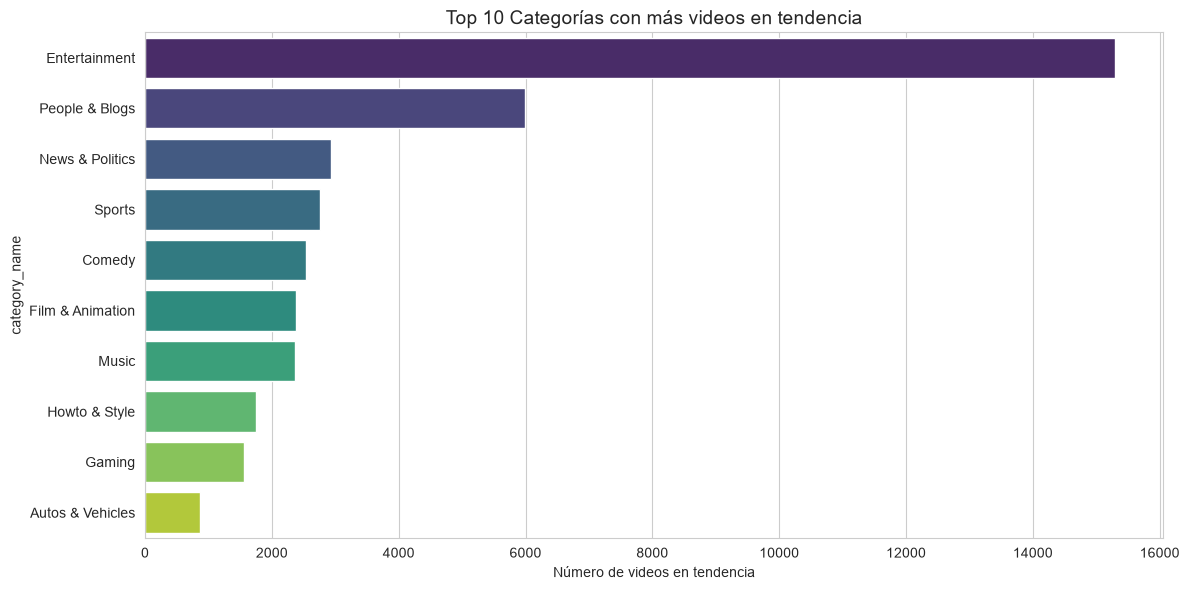

In [11]:
# --- Q1: Categorías con mayor tendencia (frecuencia) ---
plt.figure(figsize=(12, 6))
top_categories = df['category_name'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis', legend=False)
plt.title('Top 10 Categorías con más videos en tendencia', fontsize=14)
plt.xlabel('Número de videos en tendencia')
plt.tight_layout()
plt.show()

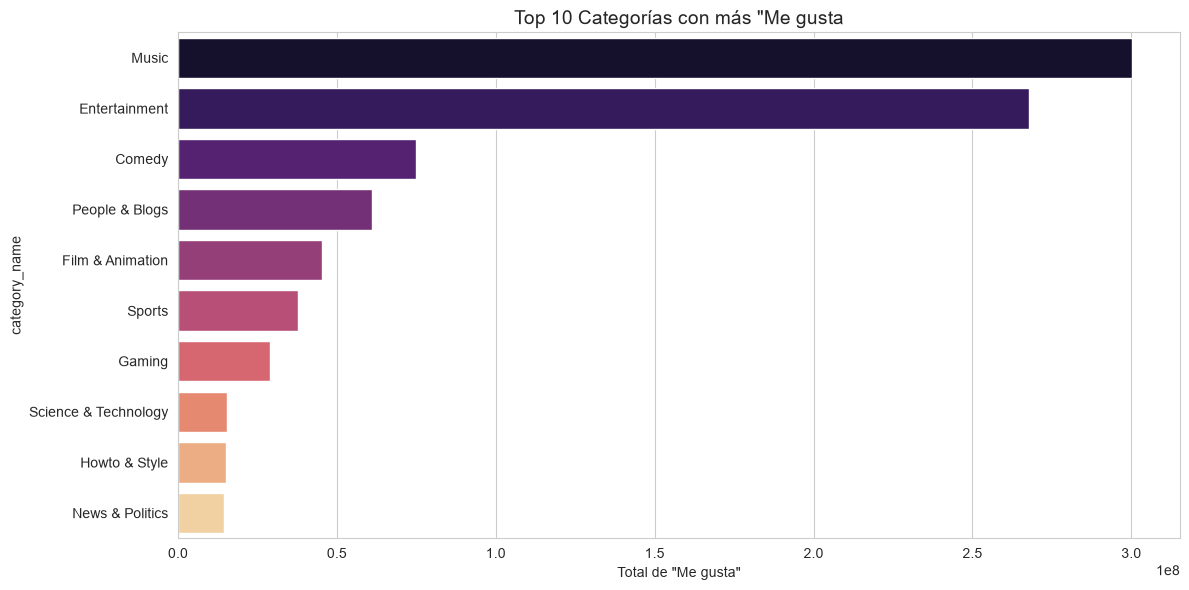

In [17]:
# --- Q2: Categorías que más gustan (suma de likes) ---
likes_by_cat = df.groupby('category_name')['likes'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=likes_by_cat.values, y=likes_by_cat.index, hue=likes_by_cat.index, palette='magma', legend=False)
plt.title('Top 10 Categorías con más "Me gusta', fontsize=14)
plt.xlabel('Total de "Me gusta"')
plt.tight_layout()
plt.show()

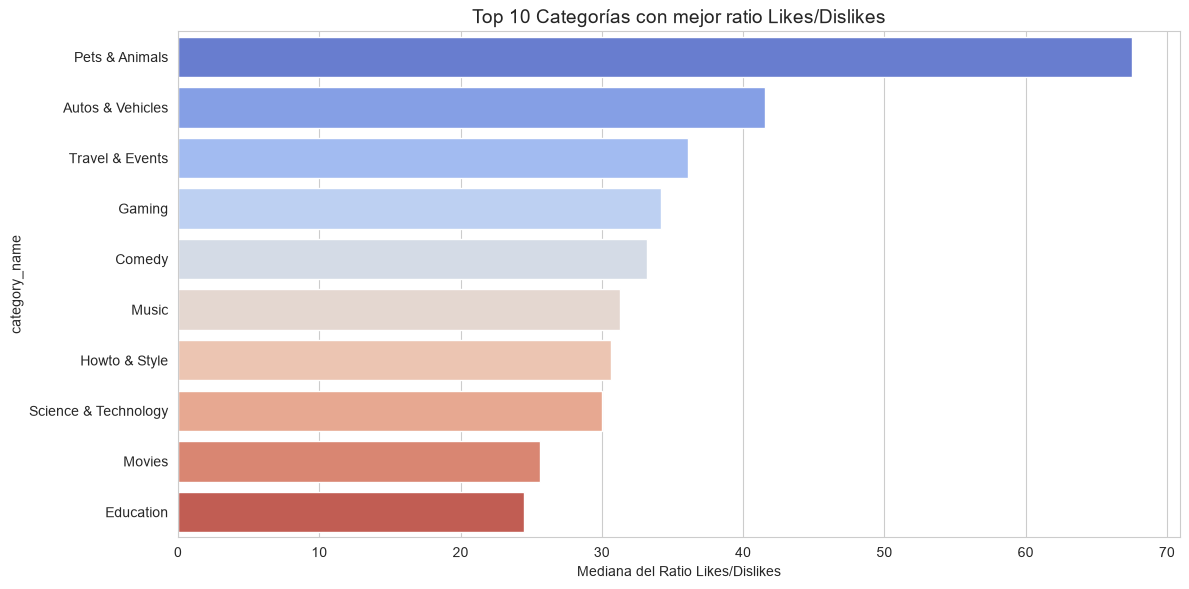

In [18]:
# --- Q3: Categorías con mejor ratio Likes/dislikes ---
# Usamos la mediana para evitar que outliers distorsionen (más robusto)
ratio_by_cat = df.groupby('category_name')['likes/dislikes'].median().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=ratio_by_cat.values, y=ratio_by_cat.index, hue=ratio_by_cat.index, palette='coolwarm', legend=False)
plt.title('Top 10 Categorías con mejor ratio Likes/Dislikes', fontsize=14)
plt.xlabel('Mediana del Ratio Likes/Dislikes')
plt.tight_layout()
plt.show()

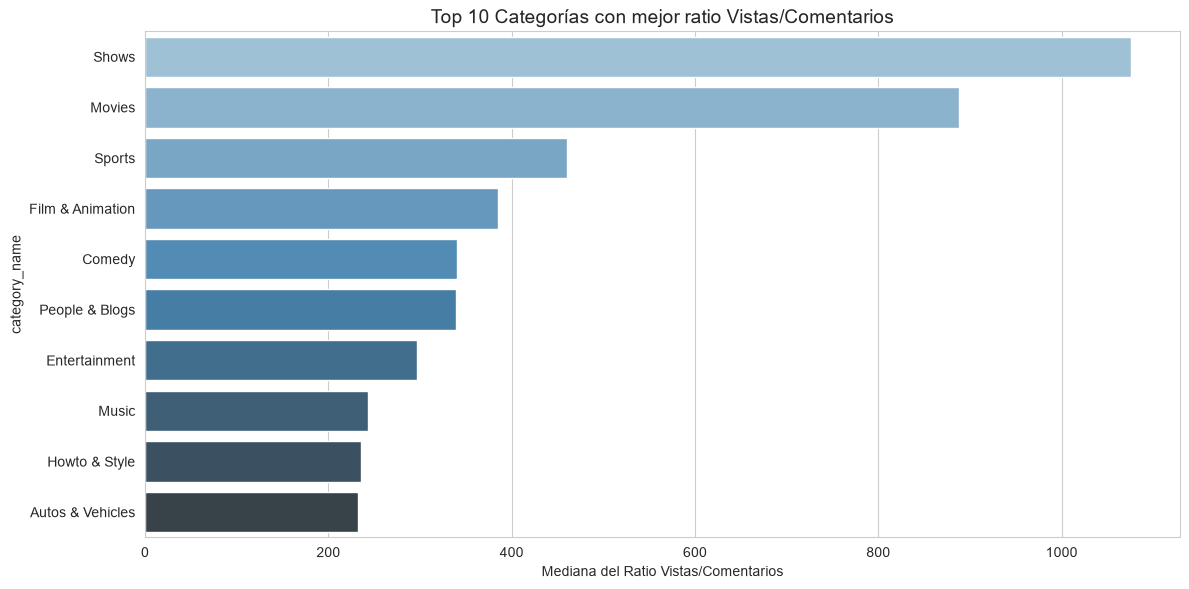

In [19]:
# --- Q4: Categorías con mejor ratio Views/Comments ---
# Calculamos el ratio vistas/comentarios
df['views/comments'] = df['views'] / df['comment_count']
# Reemplazar infinitos (comment_count=0) por NaN
df['views/comments'] = df['views/comments'].replace([np.inf, -np.inf], np.nan)

ratio_vc_by_cat = df.groupby('category_name')['views/comments'].median().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=ratio_vc_by_cat.values, y=ratio_vc_by_cat.index, hue=ratio_vc_by_cat.index, palette='Blues_d', legend=False)
plt.title('Top 10 Categorías con mejor ratio Vistas/Comentarios', fontsize=14)
plt.xlabel('Mediana del Ratio Vistas/Comentarios')
plt.tight_layout()
plt.show()

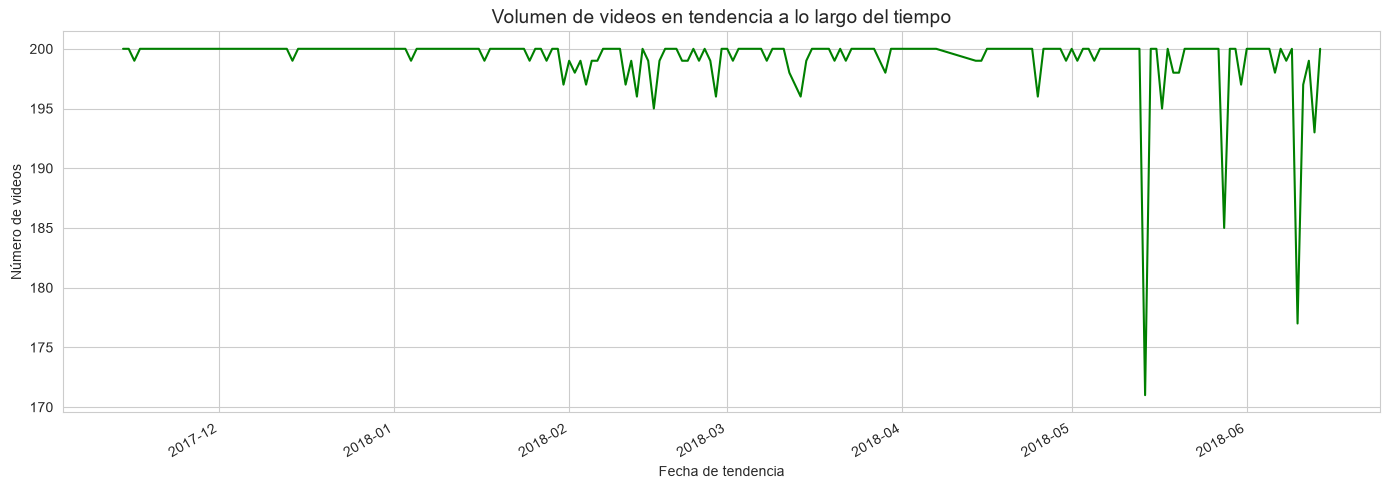

In [20]:
# --- Q5: Evolución del volumen de tendencias a lo largo del tiempo ---
trends_by_date = df.groupby('trending_date')['video_id'].count()
plt.figure(figsize=(14, 5))
trends_by_date.plot(kind='line', color='green')
plt.title('Volumen de videos en tendencia a lo largo del tiempo', fontsize=14)
plt.xlabel('Fecha de tendencia')
plt.ylabel('Número de videos')
plt.tight_layout()
plt.show()

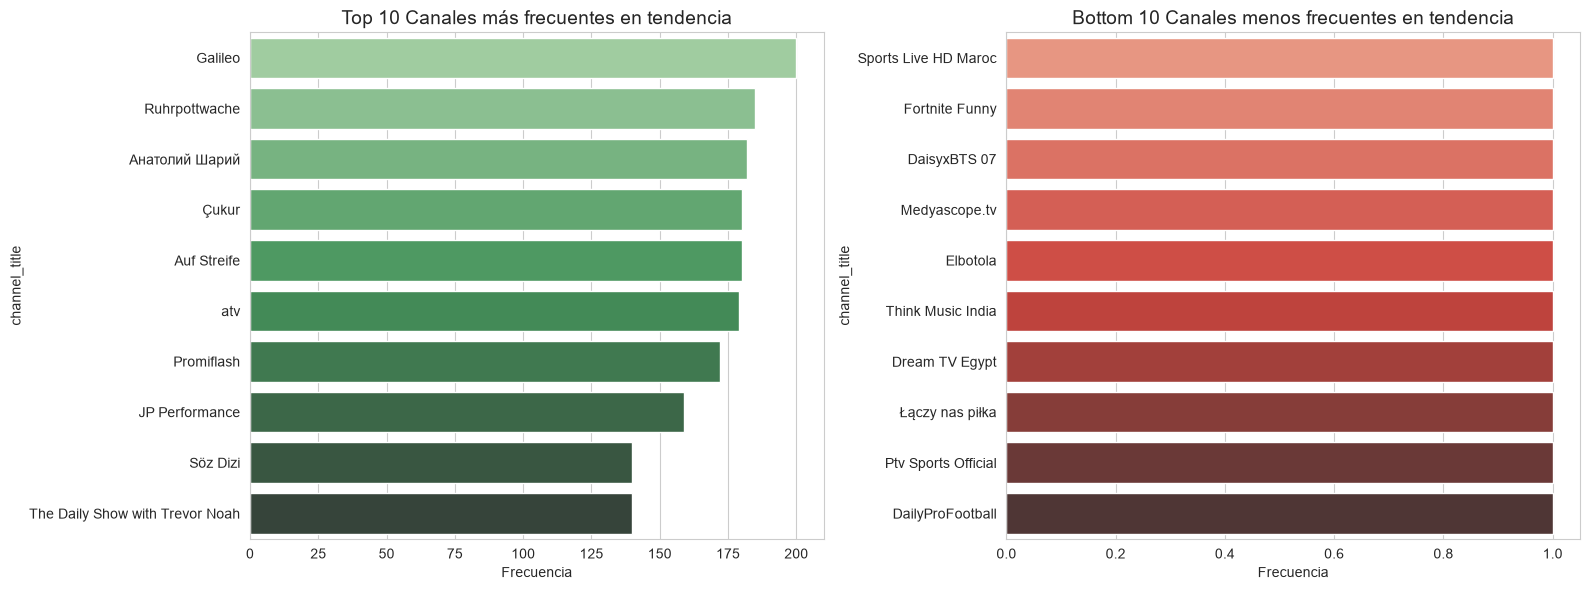

In [21]:
# --- Q6: Canales más y menos frecuentes en tendencia ---
top_channels = df['channel_title'].value_counts().head(10)
bottom_channels = df['channel_title'].value_counts().tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=top_channels.values, y=top_channels.index, hue=top_channels.index, ax=axes[0], palette='Greens_d', legend=False)
axes[0].set_title('Top 10 Canales más frecuentes en tendencia', fontsize=14)
axes[0].set_xlabel('Frecuencia')

sns.barplot(x=bottom_channels.values, y=bottom_channels.index, hue=bottom_channels.index, ax=axes[1], palette='Reds_d', legend=False)
axes[1].set_title('Bottom 10 Canales menos frecuentes en tendencia', fontsize=14)
axes[1].set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

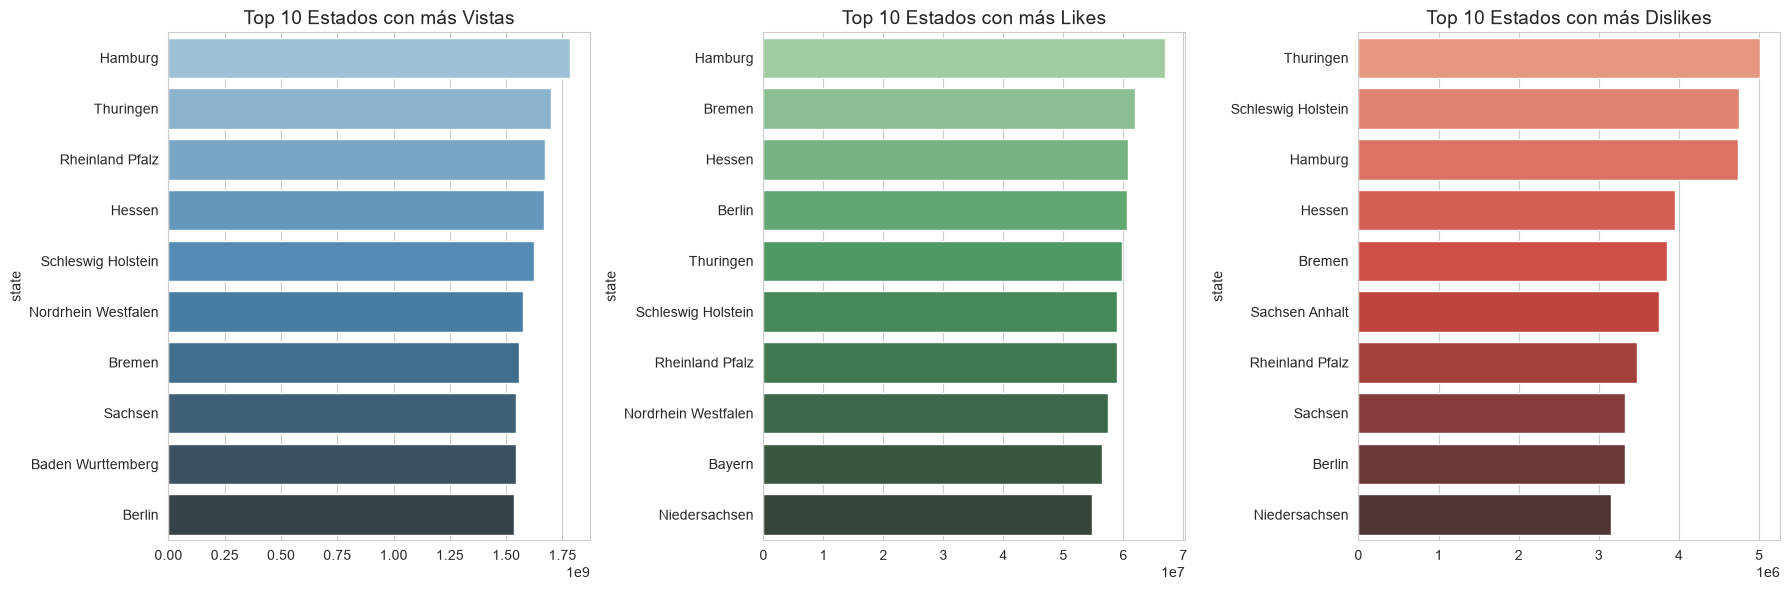

In [22]:
# --- Q7: Estados con mayor número de vistas, likes y dislikes ---
# (Nota: los estados son aleatorios según el enunciado, pero igual los graficamos)
state_views = df.groupby('state')['views'].sum().sort_values(ascending=False).head(10)
state_likes = df.groupby('state')['likes'].sum().sort_values(ascending=False).head(10)
state_dislikes = df.groupby('state')['dislikes'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.barplot(x=state_views.values, y=state_views.index, hue=state_views.index, ax=axes[0], palette='Blues_d', legend=False)
axes[0].set_title('Top 10 Estados con más Vistas', fontsize=14)
sns.barplot(x=state_likes.values, y=state_likes.index, hue=state_likes.index, ax=axes[1], palette='Greens_d', legend=False)
axes[1].set_title('Top 10 Estados con más Likes', fontsize=14)
sns.barplot(x=state_dislikes.values, y=state_dislikes.index, hue=state_dislikes.index, ax=axes[2], palette='Reds_d', legend=False)
axes[2].set_title('Top 10 Estados con más Dislikes', fontsize=14)
plt.tight_layout()
plt.show()

<Axes: >

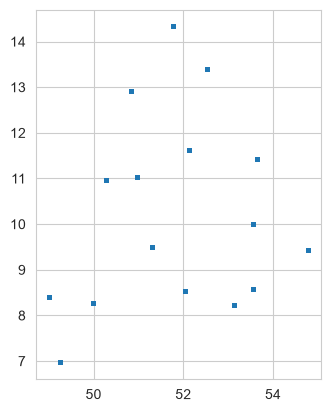

In [12]:
gdf = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df["lat"],df["lon"]), crs="EPSG:4326")

gdf.plot(markersize=5)

In [13]:
estados = (
    df.groupby("state")
      .agg({
          "lat": "mean",
          "lon": "mean",
          "views": "sum",
          "likes": "sum",
          "dislikes": "sum"
      })
      .reset_index()
)

estados.head()

,state,lat,lon,views,likes,dislikes
0,Baden Wurttemberg,48.999992,8.399993,1542170061,53931077,2926202
1,Bayern,50.266607,10.966607,1456903369,56428535,2952057
2,Berlin,52.521819,13.401549,1535553735,60643112,3329344
3,Brandenburg,51.770418,14.329967,1416692239,48026671,3110545
4,Bremen,53.550438,8.579982,1556155587,61946034,3852057


<Axes: >

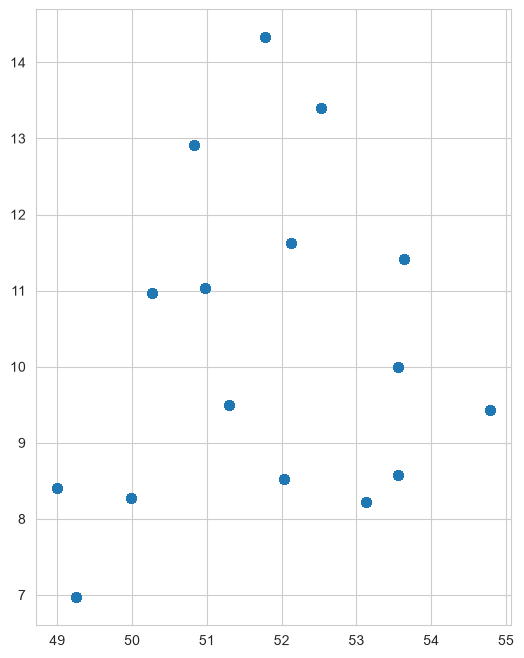

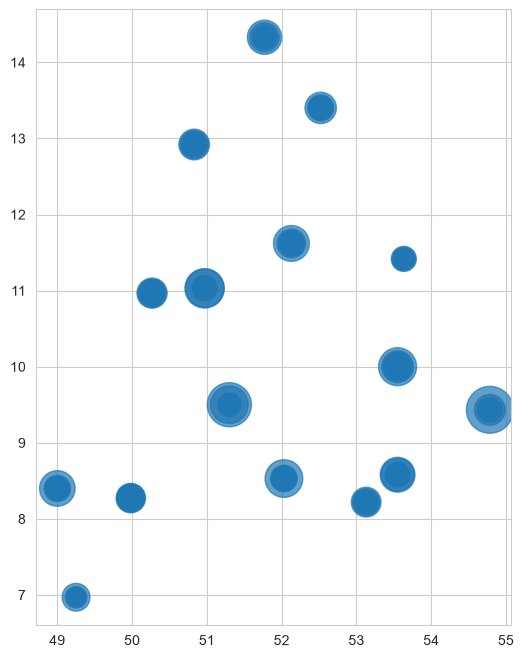

In [14]:
gdf.plot(figsize=(10,8), markersize=40)
gdf.plot(
    figsize=(10,8),
    markersize=gdf["views"]/100000,
    alpha=0.7
)

In [ ]:
m = folium.Map(
    location=[gdf.lat.mean(), gdf.lon.mean()],
    zoom_start=5
)

In [ ]:
for _, fila in gdf.iterrows():
    folium.Marker(
        [fila["lat"], fila["lon"]],
        popup=f"""
        <b>{fila['state']}</b><br>
        Views: {fila['views']}<br>
        Likes: {fila['likes']}<br>
        Dislikes: {fila['dislikes']}
        """
    ).add_to(m)

# Se supone que debería haber un gráfico pero no sale cuando lo corro

### Selección numérica de variables independientes (para justificar el modelo Q9)

In [22]:
# 6.1 Preparar los datos para la selección
# Transformamos views a logaritmo para estabilizar varianza y hacerla más lineal
df['log_views'] = np.log1p(df['views'])

# Seleccionar las columnas candidatas a independientes (válidas)
candidate_features = [
    'days_to_trend', 'hour_published', 'weekday_published', 
    'num_tags', 'title_length', 'desc_length', 
    'comments_disabled', 'ratings_disabled'
]

# 6.2 Correlación de Spearman (mide relación monótona, robusta para datos no lineales)
spearman_results = {}
for col in candidate_features:
    corr, p_val = spearmanr(df[col], df['log_views'])
    spearman_results[col] = {'correlation': corr, 'p_value': p_val}

# Ordenar por correlación absoluta (de mayor a menor)
sorted_spearman = sorted(spearman_results.items(), key=lambda x: abs(x[1]['correlation']), reverse=True)

print("\n=== Correlación de Spearman con log(views) ===")
for col, values in sorted_spearman:
    print(f"{col}: rho = {values['correlation']:.4f} (p = {values['p_value']:.4e})")

# 6.3 Información Mutua (captura relaciones no lineales y funciona con categóricas)
# Preparamos X con todas las candidatas (incluyendo categóricas)
X = df[candidate_features + ['category_id', 'channel_title', 'state']].copy()

# Para MI, las categóricas deben ser codificadas como enteros (ya lo son category_id, pero channel_title y state son strings)
# Usamos LabelEncoder (pero para MI no importa el orden, solo la cardinalidad)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['channel_title_enc'] = le.fit_transform(X['channel_title'])
X['state_enc'] = le.fit_transform(X['state'])
# category_id ya es numérico, lo dejamos

# Seleccionamos las columnas finales para MI
mi_features = ['days_to_trend', 'hour_published', 'weekday_published', 
               'num_tags', 'title_length', 'desc_length', 
               'comments_disabled', 'ratings_disabled',
               'category_id', 'channel_title_enc', 'state_enc']

# Calcular Información Mutua (más lento, pero muy informativo)
mi_scores = mutual_info_regression(X[mi_features], df['log_views'], random_state=42)

mi_results = dict(zip(mi_features, mi_scores))
sorted_mi = sorted(mi_results.items(), key=lambda x: x[1], reverse=True)

print("\n=== Información Mutua con log(views) ===")
for col, score in sorted_mi:
    print(f"{col}: MI = {score:.4f}")


=== Correlación de Spearman con log(views) ===
days_to_trend: rho = 0.3360 (p = 0.0000e+00)
title_length: rho = -0.1196 (p = 5.3627e-130)
num_tags: rho = 0.1178 (p = 4.6003e-126)
desc_length: rho = 0.0685 (p = 1.0895e-43)
ratings_disabled: rho = -0.0678 (p = 7.9291e-43)
hour_published: rho = 0.0611 (p = 4.8547e-35)
comments_disabled: rho = -0.0416 (p = 4.1558e-17)
weekday_published: rho = 0.0027 (p = 5.8036e-01)

=== Información Mutua con log(views) ===
channel_title_enc: MI = 0.2721
category_id: MI = 0.1020
days_to_trend: MI = 0.0972
desc_length: MI = 0.0642
hour_published: MI = 0.0570
num_tags: MI = 0.0415
title_length: MI = 0.0344
state_enc: MI = 0.0031
ratings_disabled: MI = 0.0028
comments_disabled: MI = 0.0022
weekday_published: MI = 0.0006


In [ ]:
# USANDO EL MÉTODO DE REGRESIÓN LINEAL

In [11]:
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,lon,geometry,category_name,days_to_trend,hour_published,weekday_published,num_tags,title_length,desc_length,likes/dislikes
0,LgVi6y5QIjM,2017-11-14,Sing zu Ende! | Gesangseinlagen vom Feinsten |...,inscope21,24,2017-11-13 17:08:49,"inscope21|""sing zu ende""|""gesangseinlagen""|""ge...",252786,35885,230,...,9.433315,POINT (9.433315388 54.78374778),Entertainment,0,17,0,16,56,636,156.021739
1,Bayt7uQith4,2017-11-14,Kinder ferngesteuert im Kiosk! Erwachsene abzo...,LUKE! Die Woche und ich,23,2017-11-12 22:30:01,"Kinder|""ferngesteuert""|""Kinder ferngesteuert""|...",797196,53576,302,...,8.530011,POINT (8.530011351000001 52.02998822),Comedy,1,22,6,27,84,726,177.403974
2,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97190,6146,...,6.970003,POINT (6.970003213 49.25039044),Entertainment,0,7,0,4,62,630,15.813537
3,AHtypnRk7JE,2017-11-14,Das Fermi-Paradoxon,100SekundenPhysik,27,2017-11-12 15:00:01,"Physik|""Wissenschaft""|""Technik""|""Science-Ficti...",380247,31821,458,...,10.966607,POINT (10.96660681 50.26660748),Education,1,15,6,9,19,259,69.478166
4,ZJ9We4bjcg0,2017-11-14,18 SONGS mit Kelly MissesVlog (Sing-off),rezo,24,2017-11-12 13:10:36,"kelly|""missesvlog""|""kelly song""|""bausa""|""bausa...",822213,100684,2467,...,13.401549,POINT (13.40154862 52.52181866),Entertainment,1,13,6,5,40,357,40.812323


In [12]:
# Definiendo variables independientes

X = df.drop(['views'],axis=1)



In [ ]:
#Definiendo variable dependiente
y = df.views

In [14]:
numericas = X.select_dtypes(include=('int64','float64')).columns.tolist()

numericas

['category_id',
 'likes',
 'dislikes',
 'comment_count',
 'comments_disabled',
 'ratings_disabled',
 'lat',
 'lon',
 'days_to_trend',
 'num_tags',
 'title_length',
 'desc_length',
 'likes/dislikes']